# McLaren 570S GT4 × Nürburgring Combined telemetry audit

This notebook decides which downstream capabilities the four frozen
iRacing `.ibt` recordings can safely support. The analytical grain is
one immutable telemetry record (nominally 60 Hz); the downstream use
is deterministic replay, lap segmentation, fuel estimation, and later
corner-level coaching.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import polars as pl

ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

from scripts.build_quality_notebook import load_quality_notebook_inputs
from iracing_ai_engineer.ibt import IbtReader, sha256_file
from iracing_ai_engineer.quality import analyze_ibt
from iracing_ai_engineer.replay import replay_ibt

RAW_DIR = ROOT / "data" / "raw"
manifest, paths = load_quality_notebook_inputs(ROOT)
reports = [analyze_ibt(path) for path in paths]
primary_path = RAW_DIR / manifest["primary_sample"]
primary = next(report for report in reports if Path(report.source_path) == primary_path)

## TL;DR

In [2]:
summary = pl.DataFrame([report.summary_row() for report in reports])
display(summary)

print(
    f"{len(reports)}/{len(reports)} files are replay-readable; "
    f"{sum(r.capabilities.lap_ready for r in reports)} is lap-ready."
)
print(
    f"Primary sample: "
    f"{sum(lap.structurally_complete for lap in primary.laps)} structural laps, "
    f"{sum(lap.clean_for_driving for lap in primary.laps)} clean lap."
)
print(
    "Decision: keep fuel modeling and comparative driving coaching disabled; "
    "the current data is sufficient for Stage 0 replay/lap-pipeline validation only."
)

file,size_mb,records,tick_rate_hz,duration_s,declared_laps,structural_laps,quality_complete_laps,clean_driving_laps,fuel_eligible_laps,dropped_ticks,replay_readable,lap_ready,fuel_ready,driving_ready,coaching_evidence_ready
str,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,bool,bool,bool,bool,bool
"""mclaren570sgt4_nurburgring com…",18.969,17663,60,294.417,1,0,0,0,0,3,true,false,false,false,false
"""mclaren570sgt4_nurburgring com…",14.401,13410,60,223.55,1,0,0,0,0,0,true,false,false,false,false
"""mclaren570sgt4_nurburgring com…",30.804,28776,60,479.567,2,0,0,0,0,0,true,false,false,false,false
"""mclaren570sgt4_nurburgring com…",85.473,80012,60,1333.583,5,1,1,0,1,0,true,true,false,false,false


4/4 files are replay-readable; 1 is lap-ready.
Primary sample: 1 structural laps, 0 clean lap.
Decision: keep fuel modeling and comparative driving coaching disabled; the current data is sufficient for Stage 0 replay/lap-pipeline validation only.


## Context & methods

The check is capability-oriented rather than a single pass/fail:

- `replay_readable`: fixed-width payload, finite ordered session time,
  and exact record boundary.
- `lap_ready`: at least one conservative boundary-to-boundary lap.
- `fuel_ready`: at least two complete no-pit laps with measurable burn.
- `driving_ready`: at least three clean laps for an algorithm smoke test.
- `coaching_evidence_ready`: reserved and disabled until a trusted
  condition-cohort receipt and independently authenticated labels
  are attached; it also requires at least eight matched clean laps.

A distance wrap plus lap-counter evidence is preferred. Counter-only
boundaries near start/finish are retained at lower confidence. Pit,
incident, off-track, reset, gap, and partial-lap labels remain explicit.

Assumptions: these 2025 recordings are dry, from one car/track schema;
SessionInfo is used only for a non-driver public subset. Current-stint
tire wear is not treated as directly measured.

## Data provenance and integrity

In [3]:
expected = {item["file_name"]: item for item in manifest["files"]}
provenance_rows = []
for path in paths:
    digest = sha256_file(path)
    item = expected[path.name]
    provenance_rows.append(
        {
            "file": path.name,
            "bytes": path.stat().st_size,
            "sha256": digest,
            "manifest_match": digest == item["sha256"]
            and path.stat().st_size == item["byte_size"],
        }
    )
provenance = pl.DataFrame(provenance_rows)
assert provenance["manifest_match"].all()
display(provenance)

context = primary.session_context
print(
    {
        "track": context["track_display_name"],
        "track_length": context["track_length"],
        "event_type": context["event_type"],
        "sim_build": context["sim_build"],
        "driver_info_exported": manifest["privacy"]["driver_info_exported"],
    }
)

file,bytes,sha256,manifest_match
str,i64,str,bool
"""mclaren570sgt4_nurburgring com…",18968740,"""3538410ebefe0c907969f104b132e7…",true
"""mclaren570sgt4_nurburgring com…",14401135,"""b1f8c621cd67b47a51d36de2c1d210…",true
"""mclaren570sgt4_nurburgring com…",30804368,"""74e09319f05db81d077fdcc997e36b…",true
"""mclaren570sgt4_nurburgring com…",85473151,"""f7c4925cd064ee1d364ddbf0d45dad…",true


{'track': 'Gesamtstrecke 24h', 'track_length': '25.18 km', 'event_type': 'Race', 'sim_build': '2025.05.06.01', 'driver_info_exported': False}


## Primary-sample gates and field coverage

In [4]:
gate_rows = [
    {
        "gate": gate.gate_id,
        "status": gate.status,
        "metric": gate.metric,
        "threshold": gate.threshold,
    }
    for gate in primary.gates
]
display(pl.DataFrame(gate_rows))

focus_fields = {
    "SessionTime", "SessionTick", "Lap", "LapCompleted", "LapDistPct",
    "Speed", "Throttle", "Brake", "SteeringWheelAngle", "Gear", "RPM",
    "FuelLevel", "FuelLevelPct", "OnPitRoad", "PlayerCarInPitStall",
    "PlayerTrackSurface", "PlayerCarMyIncidentCount",
}
field_rows = [
    {
        "field": item.name,
        "present": item.present,
        "finite_fraction": item.finite_fraction,
        "minimum": item.minimum,
        "maximum": item.maximum,
    }
    for item in primary.field_stats
    if item.name in focus_fields
]
display(pl.DataFrame(field_rows))

gate,status,metric,threshold
str,str,str,str
"""record_layout""","""PASS""","""trailing_bytes=0""","""0 trailing bytes"""
"""channel_shapes""","""PASS""","""all_selected_channels_match_re…","""each selected channel has 8001…"
"""session_time""","""WARN""","""finite=1.0, duplicates=1, regr…","""100% finite, no regressions; d…"
"""sampling_consistency""","""PASS""","""declared_hz=60, median_step_s=…","""median SessionTime step within…"
"""tick_continuity""","""PASS""","""regressions=0, dropped=0""","""0 regressions and 0 dropped ti…"
…,…,…,…
"""structural_laps""","""PASS""","""complete_laps=1""",""">=1 boundary-to-boundary lap"""
"""quality_complete_laps""","""PASS""","""quality_complete_laps=1""",""">=1 structural lap with >=99.5…"
"""fuel_evidence""","""FAIL""","""eligible_laps=1, values_valid=…",""">=2 complete no-pit laps and v…"


field,present,finite_fraction,minimum,maximum
str,bool,f64,f64,f64
"""SessionTime""",true,1.0,705.766634,2039.349967
"""SessionTick""",true,1.0,34589.0,114600.0
"""Lap""",true,1.0,0.0,4.0
"""LapCompleted""",true,1.0,0.0,3.0
"""LapDistPct""",true,1.0,0.0,0.999993
…,…,…,…,…
"""FuelLevelPct""",true,1.0,0.230214,0.5
"""OnPitRoad""",true,1.0,0.0,1.0
"""PlayerCarInPitStall""",true,1.0,0.0,1.0


## Lap segmentation evidence

In [5]:
lap_rows = [
    {
        "ordinal": lap.ordinal,
        "source_lap": f"{lap.source_lap_start}->{lap.source_lap_end}",
        "duration_s": round(lap.duration_s, 3),
        "distance_laps": round(lap.distance_coverage_laps, 5),
        "start_boundary": lap.start_boundary,
        "end_boundary": lap.end_boundary,
        "complete": lap.structurally_complete,
        "quality_complete": lap.quality_complete,
        "clean": lap.clean_for_driving,
        "fuel_eligible": lap.fuel_eligible,
        "pit_fraction": round(lap.on_pit_road_fraction, 4),
        "incident_delta": lap.incident_delta,
        "missing_ticks": lap.missing_ticks,
        "duplicate_times": lap.duplicate_time_steps,
        "tags": ",".join(lap.tags),
        "invalid": ",".join(lap.invalid_reasons),
    }
    for lap in primary.laps
]
display(pl.DataFrame(lap_rows))

ordinal,source_lap,duration_s,distance_laps,start_boundary,end_boundary,complete,quality_complete,clean,fuel_eligible,pit_fraction,incident_delta,missing_ticks,duplicate_times,tags,invalid
i64,str,f64,f64,str,str,bool,bool,bool,bool,f64,i64,i64,i64,str,str
0,"""0->0""",0.017,0.0118,"""file_start""","""source_reset""",false,false,false,false,0.0,0,0,0,"""PARTIAL_START,STATIONARY_COUNT…","""PARTIAL_OR_DISTANCE_INCOMPLETE…"
1,"""1->1""",180.883,0.0,"""source_reset""","""source_reset""",false,false,false,false,1.0,0,0,0,"""STATIONARY_COUNTER_CHANGE,PIT_…","""PARTIAL_OR_DISTANCE_INCOMPLETE…"
2,"""2->2""",591.063,0.98821,"""source_reset""","""strong_wrap""",false,false,false,false,0.0647,1,0,0,"""STATIONARY_COUNTER_CHANGE,PIT_…","""PARTIAL_OR_DISTANCE_INCOMPLETE…"
3,"""3->3""",551.507,1.00002,"""strong_wrap""","""strong_wrap""",true,true,false,true,0.0,0,0,1,"""""","""TIME_DUPLICATE"""
4,"""4->4""",10.113,0.01521,"""strong_wrap""","""file_end""",false,false,false,false,0.0,0,0,0,"""PARTIAL_END""","""PARTIAL_OR_DISTANCE_INCOMPLETE"""


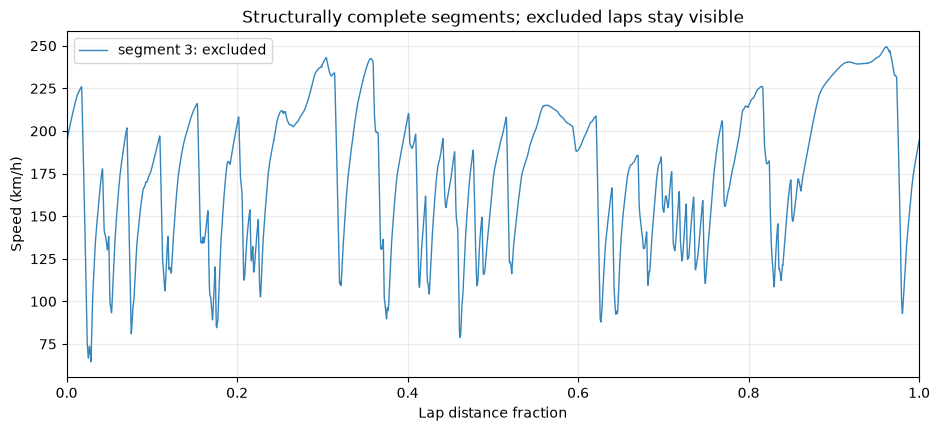

In [6]:
with IbtReader(primary_path) as reader:
    trace = reader.get_channels(("LapDistPct", "Speed"))

fig, ax = plt.subplots(figsize=(11, 4.5))
for lap in primary.laps:
    if not lap.structurally_complete:
        continue
    section = slice(lap.start_frame, lap.end_frame_exclusive)
    label = f"segment {lap.ordinal}: " + (
        "clean" if lap.clean_for_driving else "excluded"
    )
    ax.plot(
        trace["LapDistPct"][section],
        trace["Speed"][section] * 3.6,
        linewidth=1.0,
        alpha=0.9,
        label=label,
    )
ax.set(xlabel="Lap distance fraction", ylabel="Speed (km/h)", xlim=(0, 1))
ax.set_title("Structurally complete segments; excluded laps stay visible")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Canonical replay receipt (batch event pipeline)

In [7]:
receipt_single = replay_ibt(primary_path, frame_hash_chunk_size=1)
receipt_chunked = replay_ibt(primary_path, frame_hash_chunk_size=4096)
assert receipt_single.replay_sha256 == receipt_chunked.replay_sha256
assert (
    receipt_single.normalized_frames_sha256
    == receipt_chunked.normalized_frames_sha256
)
receipt_view = {
    "source_sha256": receipt_chunked.source_sha256,
    "schema_sha256": receipt_chunked.schema_sha256,
    "normalized_frames_sha256": receipt_chunked.normalized_frames_sha256,
    "events_sha256": receipt_chunked.events_sha256,
    "results_sha256": receipt_chunked.results_sha256,
    "replay_sha256": receipt_chunked.replay_sha256,
    "frame_count": receipt_chunked.frame_count,
    "event_count": receipt_chunked.event_count,
    "structurally_complete_lap_count": (
        receipt_chunked.structurally_complete_lap_count
    ),
    "clean_driving_lap_count": receipt_chunked.clean_driving_lap_count,
    "frame_hash_partition_invariant": True,
    "event_pipeline_mode": receipt_chunked.event_pipeline_mode,
}
receipt_view

{'source_sha256': 'f7c4925cd064ee1d364ddbf0d45dad3cf7cb13859aa36eb955d09bcaf528547e',
 'schema_sha256': '6085fd35487871a1553c3edcc24c4818943d076afcf17968fe8d00ba6351fe8d',
 'normalized_frames_sha256': '37d516678bc4c5eb4306c76ee06b7c47231f8db66092b789687445777d8e4a24',
 'events_sha256': 'f0e5865e313fa13cffff10e38f9a03003c0e627a10766bc4e5fb6fa96de7c8ad',
 'results_sha256': '0416512a73659f8ac06aea5223ded9e7d5e53d9c9e20941c762c86d1fa179f11',
 'replay_sha256': 'df1002d5f3fd4f850c5f80cc184446057daaf1aa7cebf6e57b01793cfd411431',
 'frame_count': 80012,
 'event_count': 4,
 'structurally_complete_lap_count': 1,
 'clean_driving_lap_count': 0,
 'frame_hash_partition_invariant': True,
 'event_pipeline_mode': 'batch-v1'}

## Takeaways

In [8]:
print("1. IBT decoder, schema validation, and canonical frame hashing are operational.")
print(
    "2. The primary file validates pit/reset-aware lap segmentation "
    "on real telemetry."
)
print(
    "3. The sole structural lap has a duplicate timestamp, so there "
    "are zero driving-clean laps."
)
print("4. Next data target: >=8 clean matched laps plus a session with >=2 pit stops.")
print(
    "5. M0 is still partial: live shared-memory collection remains "
    "to be implemented; the event/lap pipeline is still batch."
)

1. IBT decoder, schema validation, and canonical frame hashing are operational.
2. The primary file validates pit/reset-aware lap segmentation on real telemetry.
3. The sole structural lap has a duplicate timestamp, so there are zero driving-clean laps.
4. Next data target: >=8 clean matched laps plus a session with >=2 pit stops.
5. M0 is still partial: live shared-memory collection remains to be implemented; the event/lap pipeline is still batch.
